# Neural Attenuation Field (NAF) Demo

This notebook demonstrates the Neural Attenuation Field approach for tomographic reconstruction.

**Based on the NAF paper:**
"NAF: Neural Attenuation Fields for Sparse-View CBCT Reconstruction" 
https://arxiv.org/abs/2209.14540

**Key Concepts:**
- Uses multi-resolution hash encoding (from Instant NGP) to represent a 2D attenuation field
- Differentiable ray tracing computes line integrals using Beer-Lambert law
- Forward model: projection(r) = ∫ μ(x(t)) dt along ray r
- Training minimizes MSE between predicted and measured projections (sinogram)

## 1. Setup and Imports

In [1]:
# Add project root to path
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"Added {project_root} to Python path")

Added /myhome/sdate to Python path


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import time
import lovely_tensors as lt
lt.monkey_patch()  # Enable lovely tensors for better tensor printing

# Import NAF and related modules
from inct import (
    NeuralAttenuationField,
    NAFTrainer,
    ParallelBeamGeometry,
    create_sinogram_dataset,
    ProjectionSliceDataset,
    psnr,
    mse,
)
from inct.utils import get_model_size_bytes

# Import TomographyFolderProcessor for loading data
from sdate.datasets.projection_triplet_dataset import (
    TomographyFolderProcessor,
    load_tomography_params,
)

# Setup matplotlib
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['image.cmap'] = 'gray'

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("✅ Libraries imported successfully!")

Install with: pip install pillow-heif
Using device: cuda
✅ Libraries imported successfully!


## 2. Load Tomographic Data

We'll use the `ProjectionSliceDataset` with `use_attenuation=True` to load
preprocessed attenuation projections (sinogram data).

In [3]:
# Configuration
DATA_PATH = Path('/myhome/data/sdate/shared/compression_paper/file_12_extracted')
NUM_PROJECTIONS = 401  # Number of projections to use
TARGET_SIZE = 2048    # Resize projections for faster training

# Check if path exists
if DATA_PATH.exists():
    print(f"✅ Data path exists: {DATA_PATH}")
    
    # Load parameters
    tomo_params = load_tomography_params(DATA_PATH)
    print(f"\n📊 Tomography parameters:")
    for k, v in tomo_params.items():
        print(f"   {k}: {v}")
else:
    print(f"❌ Data path not found: {DATA_PATH}")
    print("   Please update DATA_PATH to point to your data folder.")

✅ Data path exists: /myhome/data/sdate/shared/compression_paper/file_12_extracted
✅ Found parameters in FC_13p5keV_G_LAG100_0p25ms_70mm_400p.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 401}

📊 Tomography parameters:
   num_darks: 10
   num_flats: 100
   num_projections: 401


In [4]:
# Load attenuation projections using ProjectionSliceDataset
if DATA_PATH.exists():
    dataset = ProjectionSliceDataset(
        folder_path=DATA_PATH,
        num_projections=NUM_PROJECTIONS,
        target_size=TARGET_SIZE,
        normalize_values=True,
        verbose=True,
        cache_volume=True,
        use_attenuation=True,  # This is key - use Beer's law attenuation
    )
    
    print(f"\n📊 Dataset Statistics:")
    print(f"   Volume shape: {dataset.shape}")
    print(f"   Value range: [{dataset.value_min:.4f}, {dataset.value_max:.4f}]")
    
    # Get full volume - shape is (H, W, n_projections)
    volume = dataset.get_full_volume()
    print(f"   Loaded volume shape: {volume.shape}")

✅ Found parameters in FC_13p5keV_G_LAG100_0p25ms_70mm_400p.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 401}
📂 Loaded folder: file_12_extracted
   Total TIFF files: 611
   Darks: 10, Flats: 100, Projections: 401
   Image dimensions: 2016 x 300
   Use attenuation: True
✅ Loaded cached attenuation data from .tomography_cache_atten.npz
   Range: [-0.2877, 13.8155]
ProjectionSliceDataset:
  Volume shape: (2048, 2048, 401)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 4,194,304
Loading 401 projections...
  Loaded 50/401
  Loaded 100/401
  Loaded 150/401
  Loaded 200/401
  Loaded 250/401
  Loaded 300/401
  Loaded 350/401
  Loaded 400/401
Volume shape: (2048, 2048, 401)
Total voxels: 1,681,915,904
Value range: [-0.2609, 13.7680]

📊 Dataset Statistics:
   Volume shape: (2048, 2048, 401)
   Value range: [-0.2609, 13.7680]
   Loaded volume shape: torch.Size([2048, 2048, 401])


/tmp/ipykernel_232568/2839142158.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


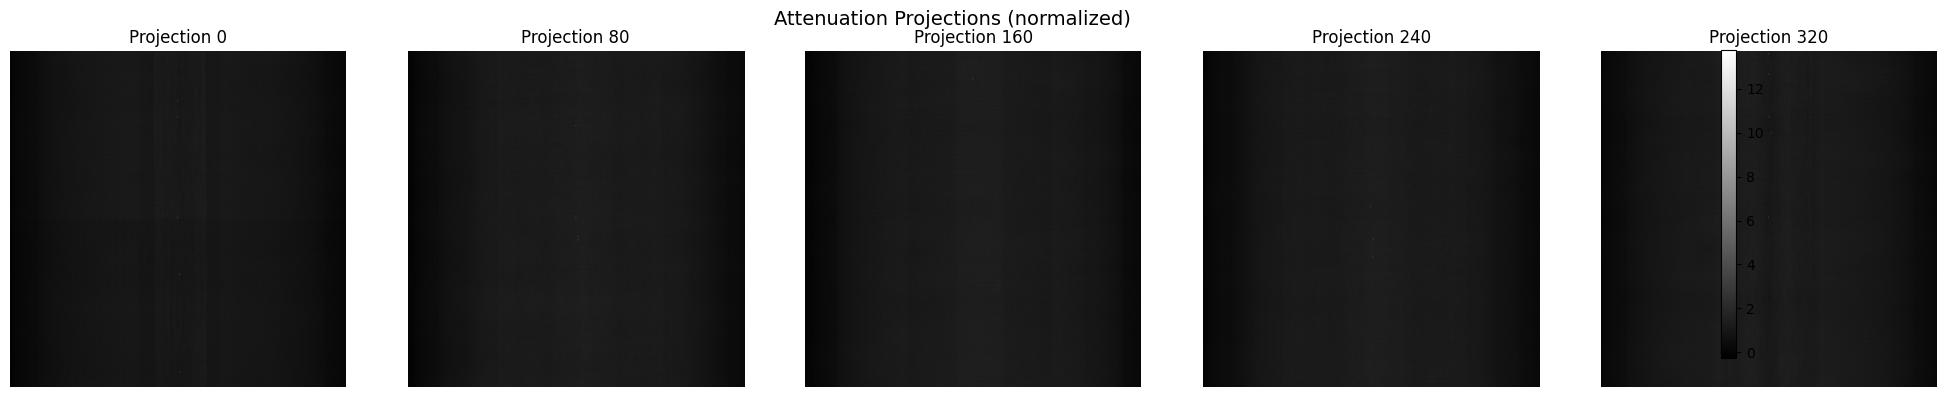

In [5]:
# Visualize some projections
if DATA_PATH.exists():
    n_show = min(5, NUM_PROJECTIONS)
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
    
    for i, ax in enumerate(axes):
        proj_idx = i * (NUM_PROJECTIONS // n_show)
        proj = volume[:, :, proj_idx]
        im = ax.imshow(proj.numpy(), vmin=volume.min(), vmax=volume.max())
        ax.set_title(f'Projection {proj_idx}')
        ax.axis('off')
    
    plt.colorbar(im, ax=axes, fraction=0.02)
    plt.suptitle('Attenuation Projections (normalized)', fontsize=14)
    plt.tight_layout()
    plt.show()

## 3. Create Sinogram and Geometry

For 2D tomographic reconstruction, we extract a single horizontal slice
(sinogram) from the projections. Each row of the sinogram corresponds to
one projection angle.

In [6]:
# Extract sinogram from the middle row of each projection
# Volume shape: (H, W, n_projections)
# Sinogram shape: (n_angles, n_detector)

H, W, N = volume.shape
mid_row = H // 2

# Extract sinogram - each projection's middle row
sinogram = volume[mid_row, :, :].T  # (n_projections, W) = (n_angles, n_detector)

print(f"Sinogram shape: {sinogram.shape}")
print(f"  n_angles = {sinogram.shape[0]}")
print(f"  n_detector = {sinogram.shape[1]}")

# Create geometry assuming projections span 180 degrees evenly
geometry = ParallelBeamGeometry(
    n_angles=sinogram.shape[0],
    n_detector=sinogram.shape[1],
    det_spacing=1.0,
    volume_size=(sinogram.shape[1], sinogram.shape[1]),  # Square volume
    angle_range=180.0,  # Projections span 180 degrees
    start_angle=0.0,
)

print(f"\n📐 Geometry:")
print(f"   Volume size: {geometry.volume_size}")
print(f"   Angle range: {geometry.start_angle}° to {geometry.start_angle + geometry.angle_range}°")
print(f"   Angles: {geometry.get_angles_deg()[:5].numpy()}... (first 5)")

Sinogram shape: torch.Size([401, 2048])
  n_angles = 401
  n_detector = 2048

📐 Geometry:
   Volume size: (2048, 2048)
   Angle range: 0.0° to 180.0°
   Angles: [0.         0.44887778 0.89775556 1.3466333  1.7955111 ]... (first 5)


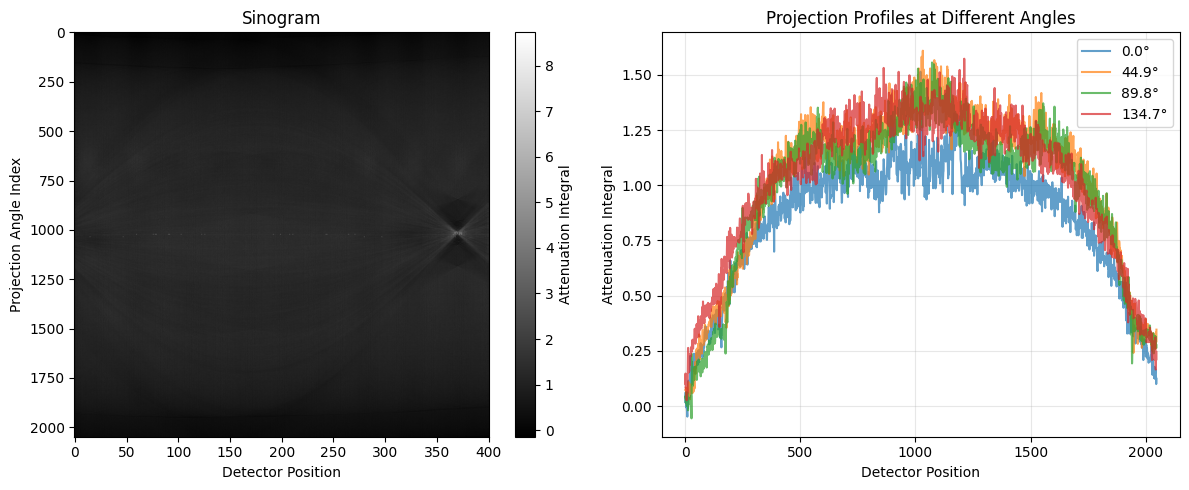

In [7]:
# Visualize the sinogram
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(sinogram.T.numpy(), aspect='auto', cmap='gray')
plt.xlabel('Detector Position')
plt.ylabel('Projection Angle Index')
plt.title('Sinogram')
plt.colorbar(label='Attenuation Integral')

plt.subplot(1, 2, 2)
# Show a few projection profiles
for i in [0, sinogram.shape[0]//4, sinogram.shape[0]//2, 3*sinogram.shape[0]//4]:
    angle = geometry.get_angles_deg()[i].item()
    plt.plot(sinogram[i].numpy(), label=f'{angle:.1f}°', alpha=0.7)
plt.xlabel('Detector Position')
plt.ylabel('Attenuation Integral')
plt.title('Projection Profiles at Different Angles')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Create and Train the NAF Model

The Neural Attenuation Field learns a continuous 2D attenuation field that,
when ray-traced, produces projections matching the input sinogram.

In [8]:
# Create NAF model
naf_model = NeuralAttenuationField(
    n_dims=2,                      # 2D attenuation field (x, y)
    n_levels=12,                   # Resolution levels
    n_features_per_level=2,        # Features per level
    base_resolution=64,            # Coarsest: 64x64
    max_resolution=2048,            # Finest: 2048x2048
    table_size=2**18,              # 256K entries per level
    hidden_dims=[64, 64, 64],          # Small MLP
    output_activation='softplus',  # Ensures non-negative attenuation
    n_samples_per_ray=2048,         # Samples along each ray
)

print(naf_model.get_model_info())

# Model size
model_size = get_model_size_bytes(naf_model)
print(f"\n📊 Model size: {model_size / 1024:.2f} KB")

NeuralAttenuationField:
  Input dims: 2
  Total parameters: 6,301,569
  Hash table params: 6,291,456 (99.8%)
  MLP params: 10,113 (0.2%)
  Encoding: 12 levels, 2 features/level
  Ray samples: 2048
  Resolutions: [64, 87, 120, 164, 225, 309, 423, 580, 795, 1090, 1494, 2047]

📊 Model size: 24616.25 KB


In [9]:
# Create trainer
trainer = NAFTrainer(
    model=naf_model,
    geometry=geometry,
    learning_rate=1e-2,
    device=device,
)

In [10]:
# Train the model
print("🚀 Starting NAF training...")
print("="*60)

start_time = time.time()
history = trainer.train(
    target_projections=sinogram,
    num_epochs=500,
    batch_angles=10,  # Use all angles (set to e.g., 20 for faster iteration)
    verbose=True,
    log_interval=1,
)
training_time = time.time() - start_time

print(f"\n✅ Training completed in {training_time:.1f}s")
print(f"   Final loss: {history['final_loss']:.6f}")

🚀 Starting NAF training...


Training NAF:   1%|          | 4/500 [00:02<05:03,  1.63it/s, loss=0.173442, lr=8.02e-03]/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
Training NAF: 100%|██████████| 500/500 [04:28<00:00,  1.86it/s, loss=0.017303, lr=0.00e+00]


✅ Training completed in 268.6s
   Final loss: 0.017303


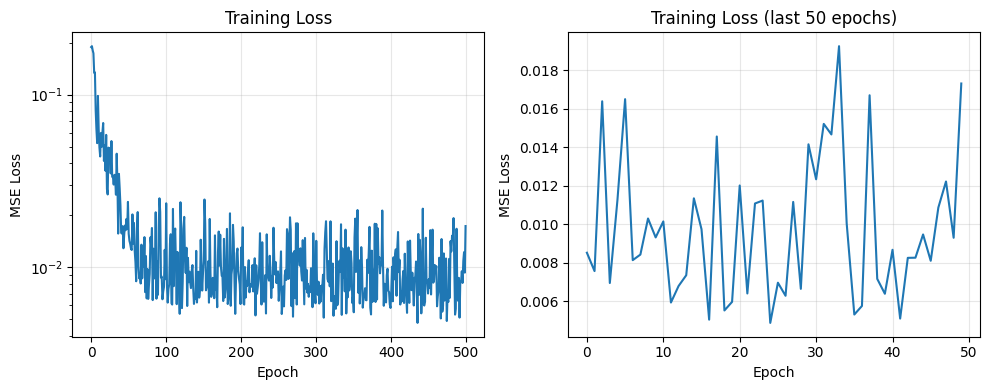

In [11]:
# Plot training history
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history['loss_history'])
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['loss_history'][-50:])
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss (last 50 epochs)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Evaluate Reconstruction Quality

In [15]:
# Evaluate projection reconstruction
metrics = trainer.evaluate(sinogram)
print(f"\n📊 Sinogram Reconstruction Quality:")
print(f"   MSE: {metrics['mse']:.6f}")
print(f"   PSNR: {metrics['psnr']:.2f} dB")

OutOfMemoryError: CUDA out of memory. Tried to allocate 12.53 GiB. GPU 0 has a total capacity of 79.25 GiB of which 290.31 MiB is free. Process 2695016 has 2.56 GiB memory in use. Process 2795335 has 76.39 GiB memory in use. Of the allocated memory 71.59 GiB is allocated by PyTorch, and 4.30 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [17]:
# Compare predicted vs target sinogram
naf_model.eval()
with torch.no_grad():
    pred_sinogram = naf_model.compute_projections(geometry).cpu()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Target sinogram
im0 = axes[0].imshow(sinogram.numpy(), aspect='auto', cmap='gray')
axes[0].set_title('Target Sinogram')
axes[0].set_xlabel('Detector')
axes[0].set_ylabel('Angle')
plt.colorbar(im0, ax=axes[0])

# Predicted sinogram
im1 = axes[1].imshow(pred_sinogram.numpy(), aspect='auto', cmap='gray', 
                     vmin=sinogram.min(), vmax=sinogram.max())
axes[1].set_title('Predicted Sinogram')
axes[1].set_xlabel('Detector')
axes[1].set_ylabel('Angle')
plt.colorbar(im1, ax=axes[1])

# Difference
diff = (sinogram - pred_sinogram).numpy()
vmax_diff = max(abs(diff.min()), abs(diff.max()))
im2 = axes[2].imshow(diff, aspect='auto', cmap='RdBu', 
                     vmin=-vmax_diff, vmax=vmax_diff)
axes[2].set_title('Difference')
axes[2].set_xlabel('Detector')
axes[2].set_ylabel('Angle')
plt.colorbar(im2, ax=axes[2])

plt.suptitle(f'Sinogram Comparison (PSNR: {metrics["psnr"]:.2f} dB)', fontsize=14)
plt.tight_layout()
plt.show()

OutOfMemoryError: CUDA out of memory. Tried to allocate 12.53 GiB. GPU 0 has a total capacity of 79.25 GiB of which 290.31 MiB is free. Process 2695016 has 2.56 GiB memory in use. Process 2795335 has 76.39 GiB memory in use. Of the allocated memory 71.60 GiB is allocated by PyTorch, and 4.30 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## 6. Reconstruct the Attenuation Volume

In [ ]:
# Predict the reconstructed 2D attenuation map
reconstruction_size = geometry.volume_size
print(f"Reconstructing {reconstruction_size[0]}x{reconstruction_size[1]} attenuation map...")

naf_model.eval()
with torch.no_grad():
    reconstructed = naf_model.predict_volume(
        shape=reconstruction_size,
        batch_size=5 * 65536,
        device=device,
    ).cpu()

print(f"Reconstructed shape: {reconstructed.shape}")
print(f"Value range: [{reconstructed.min():.4f}, {reconstructed.max():.4f}]")

Reconstructing 512x512 attenuation map...
Reconstructed shape: torch.Size([512, 512])
Value range: [0.0000, 15.5646]


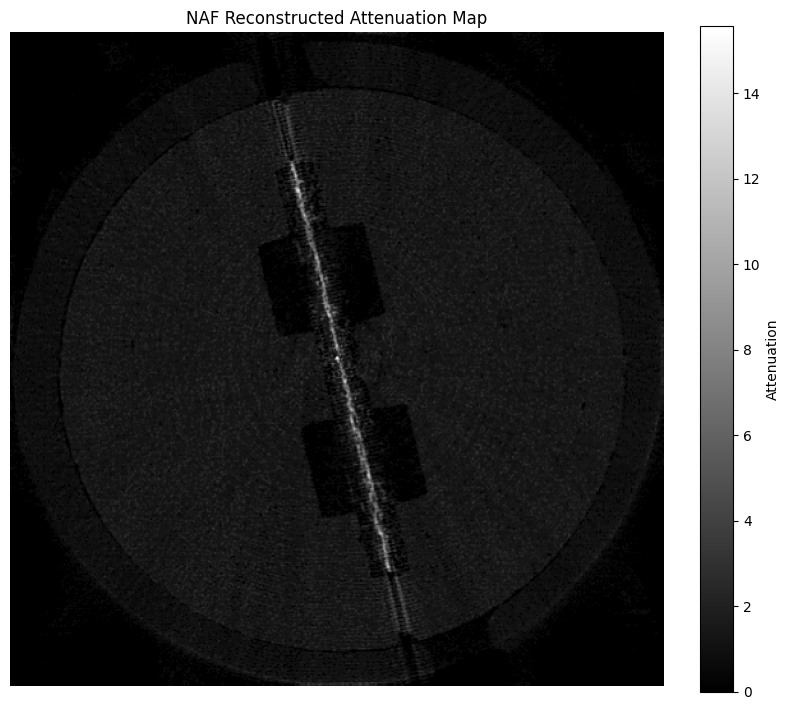

In [ ]:
# Visualize the reconstruction
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

im = ax.imshow(reconstructed.numpy(), cmap='gray')
ax.set_title('NAF Reconstructed Attenuation Map')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, label='Attenuation')

plt.tight_layout()
plt.show()

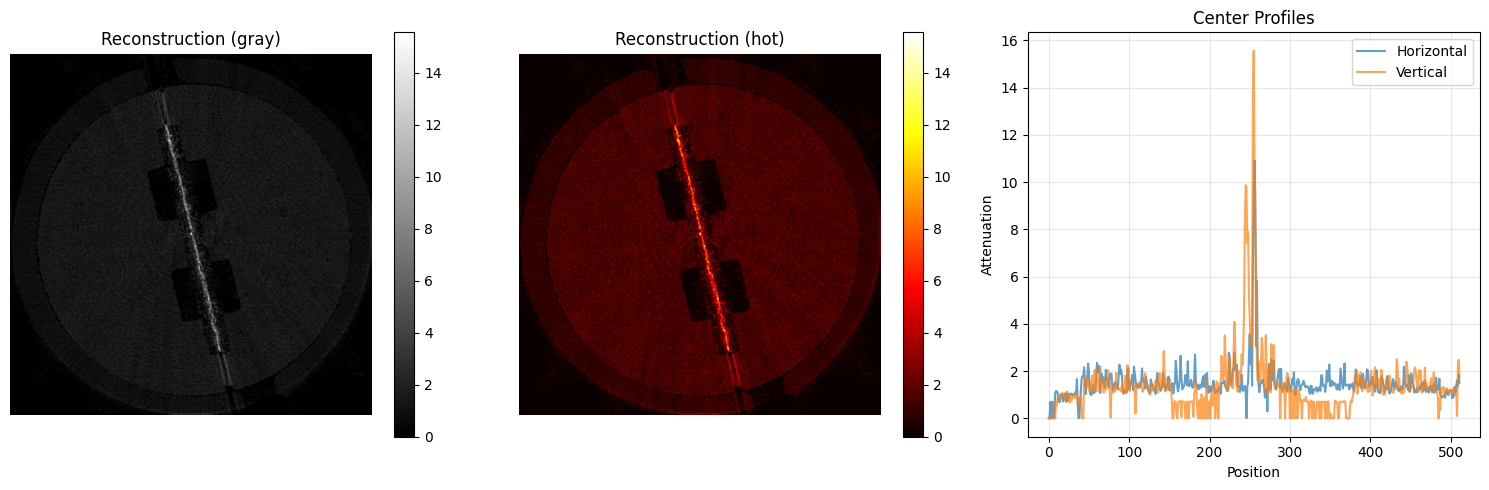

In [ ]:
# Compare with a reference reconstruction (if available)
# For now, we show the reconstructed image with different color maps

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gray colormap
im0 = axes[0].imshow(reconstructed.numpy(), cmap='gray')
axes[0].set_title('Reconstruction (gray)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0])

# Hot colormap (shows structure better)
im1 = axes[1].imshow(reconstructed.numpy(), cmap='hot')
axes[1].set_title('Reconstruction (hot)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1])

# Profile through center
center = reconstruction_size[0] // 2
axes[2].plot(reconstructed[center, :].numpy(), label='Horizontal', alpha=0.7)
axes[2].plot(reconstructed[:, center].numpy(), label='Vertical', alpha=0.7)
axes[2].set_xlabel('Position')
axes[2].set_ylabel('Attenuation')
axes[2].set_title('Center Profiles')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Save the Model

In [ ]:
# Save the trained model
save_dir = Path('checkpoints_naf')
save_dir.mkdir(exist_ok=True)

model_path = save_dir / 'naf_model.pt'
naf_model.save(str(model_path))
print(f"✅ Model saved to {model_path}")

# Also save the reconstruction
recon_path = save_dir / 'reconstruction.npy'
np.save(recon_path, reconstructed.numpy())
print(f"✅ Reconstruction saved to {recon_path}")

## 8. 3D NAF – Full Volumetric Reconstruction

Instead of reconstructing a single 2D slice, we now learn the full 3D attenuation
volume **μ(x, y, z)** from all projection images simultaneously.

**Key differences from the 2D case:**
- Network input: 3D coordinates (x, y, z) ∈ [0, 1]³
- Each projection is a full 2D image (H rows × W columns)
- Rays travel in the XY plane at the angle of each projection;
  the Z coordinate (detector row) is constant along each ray
- Training samples random batches of *(angle, detector-row)* pairs to keep GPU
  memory constant regardless of volume size


In [16]:
from inct import ParallelBeamGeometry3D, NAFTrainer3D

# ── Build 3D projection tensor ──────────────────────────────────────────────
# volume shape from ProjectionSliceDataset: (H, W, n_projections)
# We need:  (n_angles, n_det_v, n_det_u)  = (n_projections, H, W)
if DATA_PATH.exists():
    projs_3d = volume.permute(2, 0, 1)  # (n_angles, H, W)
    n_angles_3d, n_det_v, n_det_u = projs_3d.shape
    print(f"3D projection tensor: {tuple(projs_3d.shape)}")
    print(f"  n_angles  = {n_angles_3d}")
    print(f"  n_det_v   = {n_det_v}   (rows  = Z axis)")
    print(f"  n_det_u   = {n_det_u}   (cols  = horizontal detector)")

    # ── Geometry ────────────────────────────────────────────────────────────
    # Volume is (Z, Y, X) voxels – assume square XY footprint
    geometry_3d = ParallelBeamGeometry3D(
        n_angles=n_angles_3d,
        n_detector_u=n_det_u,
        n_detector_v=n_det_v,
        volume_size=(n_det_v, n_det_u, n_det_u),   # (D, H, W) = (Z, Y, X)
        angle_range=180.0,
        start_angle=0.0,
    )
    print(f"\n📐 3D Geometry:")
    print(f"  Volume size (D, H, W): {geometry_3d.volume_size}")
    print(f"  Angle range: {geometry_3d.start_angle}° → "
          f"{geometry_3d.start_angle + geometry_3d.angle_range}°")


3D projection tensor: (401, 512, 512)
  n_angles  = 401
  n_det_v   = 512   (rows  = Z axis)
  n_det_u   = 512   (cols  = horizontal detector)

📐 3D Geometry:
  Volume size (D, H, W): (512, 512, 512)
  Angle range: 0.0° → 180.0°


In [ ]:
if DATA_PATH.exists():
    # ── 3D NAF model ────────────────────────────────────────────────────────
    # n_dims=3 → the hash encoding works in 3D space (x, y, z)
    naf_model_3d = NeuralAttenuationField(
        n_dims=3,
        n_levels=12,
        n_features_per_level=2,
        base_resolution=16,
        max_resolution=512,         # effective 3D resolution at finest level
        table_size=2**20,           # 1 M entries – larger table for 3D
        hidden_dims=[128, 128, 128],
        output_activation='softplus',
        n_samples_per_ray=512,      # samples per ray along XY
    )
    n_params = sum(p.numel() for p in naf_model_3d.parameters())
    print(f"3D NAF model: {n_params:,} parameters")
    model_mb = sum(p.numel() * p.element_size() for p in naf_model_3d.parameters()) / 1e6
    print(f"Model size:   {model_mb:.1f} MB")

    # ── Trainer ─────────────────────────────────────────────────────────────
    # Memory per step ≈ batch_angles × batch_rows × n_det_u × n_samples × 3 coords
    # e.g. 10 × 10 × 512 × 512 ≈ 26 M 3D points → ~good for 16 GB GPU
    # Reduce batch_angles / batch_rows if you run out of memory.
    trainer_3d = NAFTrainer3D(
        model=naf_model_3d,
        geometry=geometry_3d,
        learning_rate=1e-3,
        device=device,
        batch_angles=20,    # angles sampled per gradient step
        batch_rows=15,     # detector rows sampled per gradient step
    )
    print("\n✅ Trainer ready")


3D NAF model: 25,176,001 parameters
Model size:   100.7 MB

✅ Trainer ready


In [18]:
if DATA_PATH.exists():
    print("🚀 Starting 3D NAF training …")
    print("=" * 60)

    NUM_EPOCHS_3D = 1000   # increase for better quality (2000–5000 for real data)

    start_time = time.time()
    history_3d = trainer_3d.train(
        target_projections=projs_3d,
        num_epochs=NUM_EPOCHS_3D,
        verbose=True,
        log_interval=1,
    )
    training_time_3d = time.time() - start_time

    print(f"\n✅ Training finished in {training_time_3d:.1f} s")
    print(f"   Final loss: {history_3d['final_loss']:.6f}")


🚀 Starting 3D NAF training …


Training 3D NAF:   0%|          | 4/1000 [00:07<32:52,  1.98s/it, loss=0.199733, lr=8.02e-04]/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
Training 3D NAF: 100%|██████████| 1000/1000 [34:48<00:00,  2.09s/it, loss=0.005997, lr=0.00e+00]


✅ Training finished in 2088.0 s
   Final loss: 0.005997


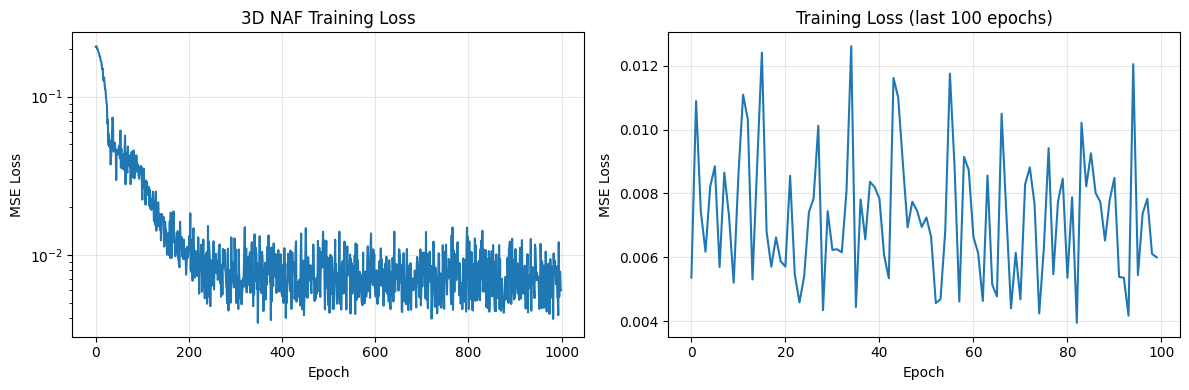

In [23]:
if DATA_PATH.exists():
    # Training loss curve
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_3d['loss_history'])
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].set_title('3D NAF Training Loss')
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)

    last = max(50, NUM_EPOCHS_3D // 10)
    axes[1].plot(history_3d['loss_history'][-last:])
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE Loss')
    axes[1].set_title(f'Training Loss (last {last} epochs)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [24]:
if DATA_PATH.exists():
    # ── Reconstruct the full 3D volume ──────────────────────────────────────
    D, H, W = geometry_3d.volume_size   # (Z, Y, X)
    print(f"Reconstructing 3D volume ({D} × {H} × {W}) …")

    naf_model_3d.eval()
    with torch.no_grad():
        # predict_volume with a 3-tuple shape returns a (D, H, W) tensor
        volume_3d = naf_model_3d.predict_volume(
            shape=(D, H, W),
            batch_size=4 * 65536,
            device=device,
        ).cpu()

    print(f"✅ Reconstruction complete: {tuple(volume_3d.shape)}")
    print(f"   Value range: [{volume_3d.min():.4f}, {volume_3d.max():.4f}]")


Reconstructing 3D volume (512 × 512 × 512) …
✅ Reconstruction complete: (512, 512, 512)
   Value range: [0.0162, 2.5373]


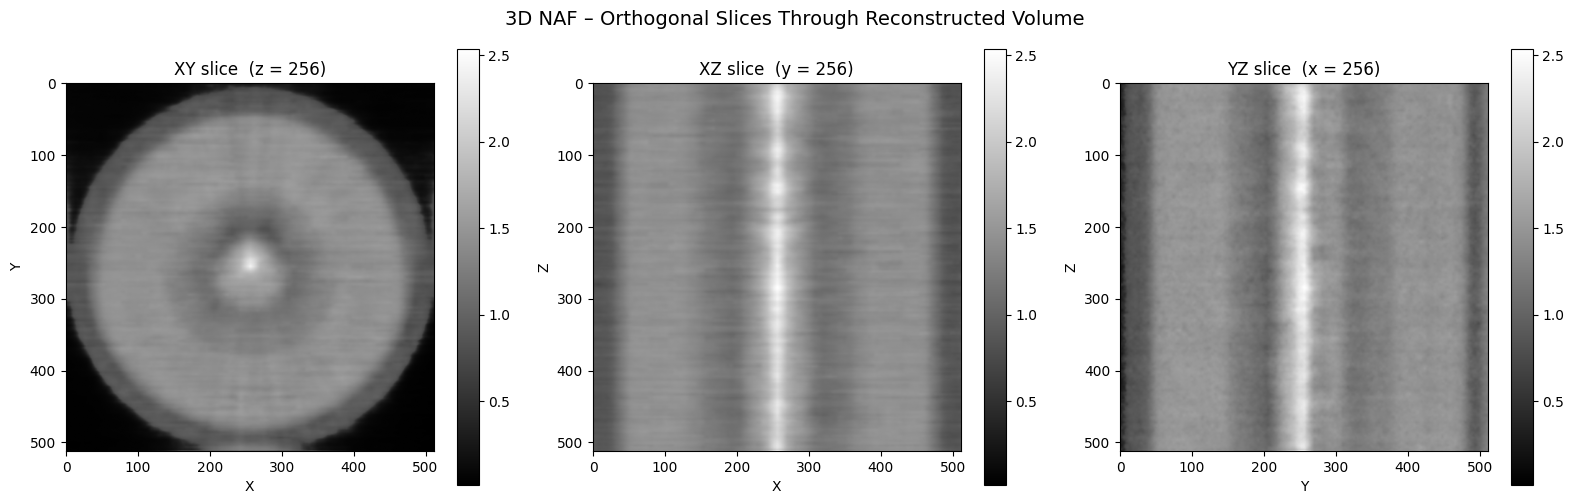

In [25]:
if DATA_PATH.exists():
    # ── Visualise orthogonal slices ─────────────────────────────────────────
    D, H, W = volume_3d.shape
    z_mid = D // 2
    y_mid = H // 2
    x_mid = W // 2

    vmin, vmax = float(volume_3d.min()), float(volume_3d.max())

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    kw = dict(cmap='gray', vmin=vmin, vmax=vmax)

    im0 = axes[0].imshow(volume_3d[z_mid].numpy(), **kw)
    axes[0].set_title(f'XY slice  (z = {z_mid})')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(volume_3d[:, y_mid, :].numpy(), **kw)
    axes[1].set_title(f'XZ slice  (y = {y_mid})')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Z')
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(volume_3d[:, :, x_mid].numpy(), **kw)
    axes[2].set_title(f'YZ slice  (x = {x_mid})')
    axes[2].set_xlabel('Y')
    axes[2].set_ylabel('Z')
    plt.colorbar(im2, ax=axes[2])

    plt.suptitle('3D NAF – Orthogonal Slices Through Reconstructed Volume',
                 fontsize=14)
    plt.tight_layout()
    plt.show()


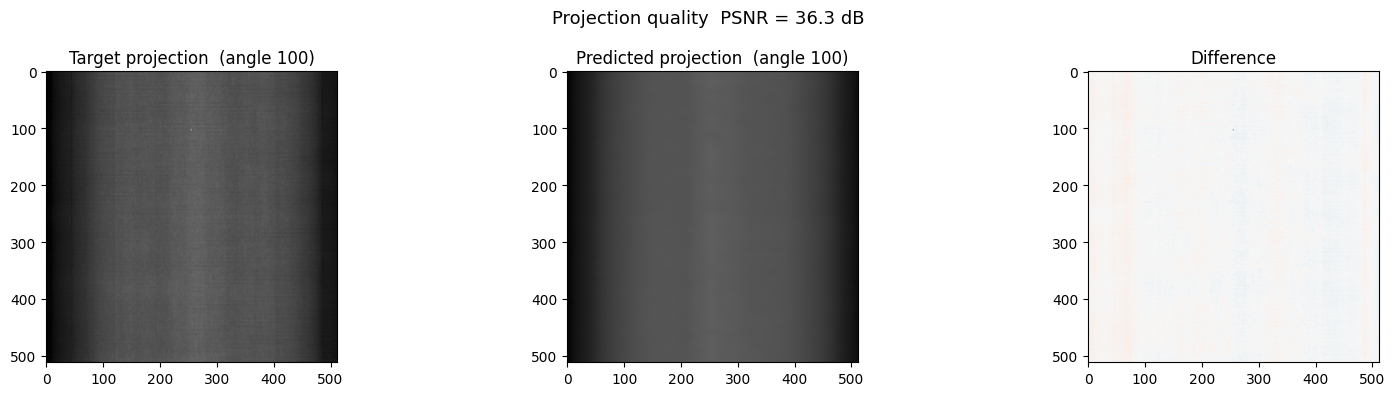

✅ 3D model saved to      checkpoints_naf/3d/naf3d_model.pt
✅ 3D volume saved to     checkpoints_naf/3d/reconstruction_3d.npy


In [26]:
if DATA_PATH.exists():
    # ── Compare a projection at one angle ───────────────────────────────────
    CHECK_ANGLE = n_angles_3d // 4   # pick a mid-range angle

    target_proj = projs_3d[CHECK_ANGLE]          # (n_det_v, n_det_u)

    naf_model_3d.eval()
    with torch.no_grad():
        pred_proj = trainer_3d.ray_tracer(
            naf_model_3d, geometry_3d,
            batch_angle_indices=torch.tensor([CHECK_ANGLE], device=device),
        ).squeeze(0).cpu()                        # (n_det_v, n_det_u)

    diff_proj = target_proj - pred_proj
    vmax_d = float(diff_proj.abs().max())

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].imshow(target_proj.numpy(), cmap='gray')
    axes[0].set_title(f'Target projection  (angle {CHECK_ANGLE})')

    axes[1].imshow(pred_proj.numpy(), cmap='gray',
                   vmin=target_proj.min(), vmax=target_proj.max())
    axes[1].set_title(f'Predicted projection  (angle {CHECK_ANGLE})')

    axes[2].imshow(diff_proj.numpy(), cmap='RdBu',
                   vmin=-vmax_d, vmax=vmax_d)
    axes[2].set_title('Difference')

    proj_mse  = float(diff_proj.pow(2).mean())
    proj_psnr = 10 * np.log10(float(target_proj.max() - target_proj.min()) ** 2
                               / proj_mse) if proj_mse > 0 else np.inf
    plt.suptitle(f'Projection quality  PSNR = {proj_psnr:.1f} dB', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── Save 3D results ─────────────────────────────────────────────────────
    save_dir_3d = Path('checkpoints_naf') / '3d'
    save_dir_3d.mkdir(parents=True, exist_ok=True)

    naf_model_3d.save(str(save_dir_3d / 'naf3d_model.pt'))
    np.save(save_dir_3d / 'reconstruction_3d.npy', volume_3d.numpy())

    print(f"✅ 3D model saved to      {save_dir_3d / 'naf3d_model.pt'}")
    print(f"✅ 3D volume saved to     {save_dir_3d / 'reconstruction_3d.npy'}")
